In [2]:
import polars as pl

# Dataloading — read each parquet once, keep both column names and numpy view
X_train_pl = pl.read_parquet("data/X_train_scaled.parquet")
X_test_pl  = pl.read_parquet("data/X_test_scaled.parquet")

feature_names = X_train_pl.columns           # used later for coefficient plot

X_train_scaled = X_train_pl.to_numpy()
X_test_scaled  = X_test_pl.to_numpy()

y_train = pl.read_parquet("data/y_train.parquet").to_numpy()
y_test  = pl.read_parquet("data/y_test.parquet").to_numpy()

In [7]:
# Model initialization - baseline

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, balanced_accuracy_score, roc_auc_score

model = LogisticRegression(l1_ratio=1.0, solver='liblinear')
model.fit(X_train_scaled, y_train.ravel())

y_pred = model.predict(X_test_scaled)
balanced_accuracy_score = balanced_accuracy_score(y_test, y_pred)
f1_score = f1_score(y_test, y_pred, average='weighted')
recall_score = recall_score(y_test, y_pred, average='weighted')
precision_score = precision_score(y_test, y_pred, average='weighted')
roc_auc_score = roc_auc_score(y_test, y_pred, average='weighted')
accuracy = accuracy_score(y_test, y_pred)
print(f1_score)
print(recall_score)
print(precision_score)
print(roc_auc_score)
print(balanced_accuracy_score)
print(accuracy)

0.8911610358071593
0.8913043478260869
0.8912311872909698
0.8888091822094691
0.8888091822094691
0.8913043478260869


### What is important?
Our most important steps where:
- missing value imputation
- reshape the response to 1d array
- normalize the data
- one hot encoding (incl. dropping the first column)

No balancing needed as we have almost balanced data as seen before. Predictive accuracy could be improved be doing some feature engineering (i.e. interactions).

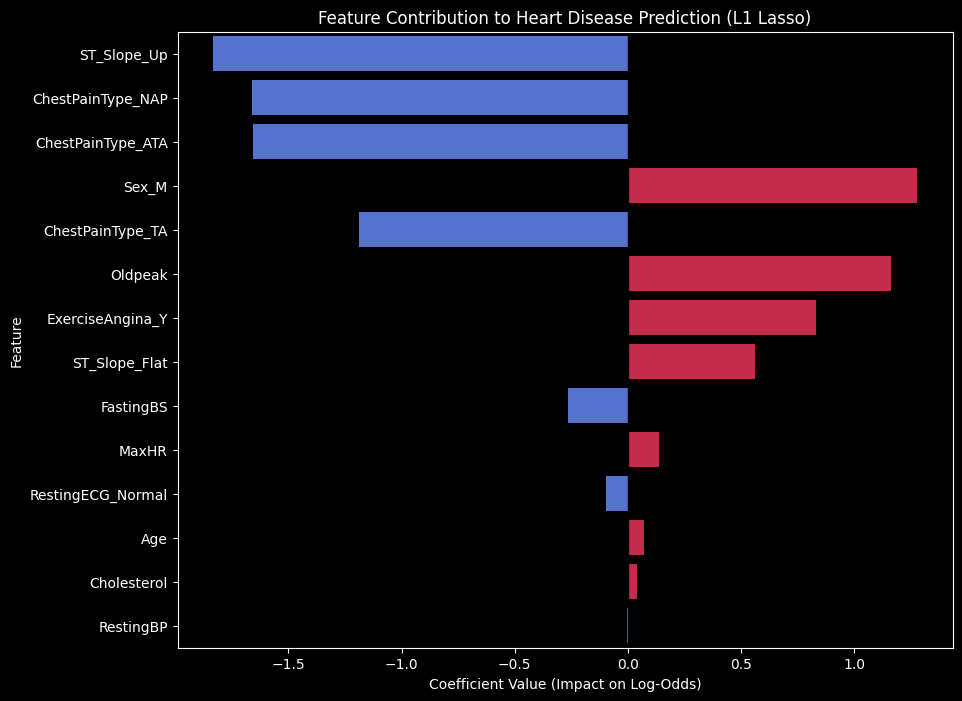

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Coefficients (feature_names already defined in the data-loading cell)
coefficients = model.coef_[0]  # sklearn wraps this in a 2D array, so we take index 0

# 2. Put them in a DataFrame for easy sorting and filtering
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
})

# 3. The L1 magic: drop features shrunk to exactly zero
importance_df = importance_df[importance_df["Coefficient"] != 0]

# 4. Sort by absolute impact
importance_df["Abs_Coefficient"] = importance_df["Coefficient"].abs()
importance_df = importance_df.sort_values(by="Abs_Coefficient", ascending=False)

# 5. Plot
plt.figure(figsize=(10, 8))
sns.barplot(
    data=importance_df,
    x="Coefficient",
    y="Feature",
    hue=importance_df["Coefficient"] > 0,
    palette={True: "crimson", False: "royalblue"},
    legend=False,
)
plt.axvline(0, color="black", linewidth=1)
plt.title("Feature Contribution to Heart Disease Prediction (L1 Lasso)")
plt.xlabel("Coefficient Value (Impact on Log-Odds)")
plt.ylabel("Feature")
plt.show()

### Q 2.5

The approach mentioned can be a valid idea, but only if a two-step approach is applied, provided that strict data splitting is used. If the researcher uses the training set exclusively for feature selection via Lasso, and then fits the unpenalized Logistic Regression on a completely separate, hold-out dataset (an 'inference set'), it is a sound strategy.

This approach solves the Lasso's limitation of massively shrinking coefficient values. Furthermore, by evaluating the p-values on unseen data, the researcher avoids post-selection inference bias. This conceptually mirrors the rule of keeping preprocessing strictly to training data to avoid data leakage, like we did in the beginning of this task.

In [10]:
### Interactions + hyperparameter tuning
#
# Two things we explore here:
#  1. pairwise feature interactions via PolynomialFeatures(interaction_only=True)
#  2. a grid search over the main LogisticRegression hyperparameters
#
# Hyperparameters we can tune:
#   - C            : inverse regularization strength (smaller C = more shrinkage)
#   - penalty      : 'l1' (sparse coefficients) vs 'elasticnet' (mix of L1+L2)
#   - l1_ratio     : only used with elasticnet (0 = pure L2, 1 = pure L1)
#   - solver       : 'liblinear' supports l1/l2; 'saga' supports elasticnet
#   - class_weight : 'balanced' if labels were skewed (here ~55/45, optional)
#   - max_iter     : raise if the solver warns about non-convergence

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    f1_score as f1_metric,
    balanced_accuracy_score as bal_acc_metric,
    roc_auc_score as roc_auc_metric,
)

pipe = Pipeline([
    # adds all pairwise products of features (no squared terms, no bias column —
    # the originals are already there from the scaled parquet).
    ("interactions", PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),
    ("clf", LogisticRegression(solver="saga", max_iter=5000)),
])

param_grid = [
    # pure L1 sweep
    {
        "interactions__degree": [1, 2],
        "clf__penalty": ["l1"],
        "clf__C": [0.01, 0.1, 1.0, 10.0],
    },
    # elasticnet sweep (mixes L1 and L2)
    {
        "interactions__degree": [1, 2],
        "clf__penalty": ["elasticnet"],
        "clf__C": [0.1, 1.0, 10.0],
        "clf__l1_ratio": [1],
    },
]

grid = GridSearchCV(
    pipe,
    param_grid,
    scoring="roc_auc",      # AUC is the cleanest single number for binary classification
    cv=5,
    n_jobs=-1,
    refit=True,
    verbose=1,
)
grid.fit(X_train_scaled, y_train.ravel())

print("Best CV ROC-AUC :", round(grid.best_score_, 4))
print("Best params     :", grid.best_params_)

# Evaluate the refit best model on the held-out test set
best = grid.best_estimator_
y_pred  = best.predict(X_test_scaled)
y_proba = best.predict_proba(X_test_scaled)[:, 1]

print("\nTest metrics (best model):")
print("  balanced acc :", round(bal_acc_metric(y_test, y_pred), 4))
print("  f1 (weighted):", round(f1_metric(y_test, y_pred, average="weighted"), 4))
print("  ROC-AUC      :", round(roc_auc_metric(y_test, y_proba), 4))
print("  accuracy      :", round(accuracy_score(y_test, y_pred), 4))



# How many interaction features survived L1?
n_total = best.named_steps["interactions"].transform(X_train_scaled[:1]).shape[1]
n_nonzero = (best.named_steps["clf"].coef_[0] != 0).sum()
print(f"\nNon-zero coefficients: {n_nonzero} / {n_total} (after L1 shrinkage)")

Fitting 5 folds for each of 14 candidates, totalling 70 fits
Best CV ROC-AUC : 0.9054
Best params     : {'clf__C': 10.0, 'clf__penalty': 'l1', 'interactions__degree': 1}

Test metrics (best model):
  balanced acc : 0.8998
  f1 (weighted): 0.902
  ROC-AUC      : 0.9303
  accuracy      : 0.9022

Non-zero coefficients: 15 / 15 (after L1 shrinkage)


c:\Users\sjaak\anaconda3\envs\ML4H\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\sjaak\anaconda3\envs\ML4H\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
